## 1. Importação das bibliotecas necessárias

In [1]:
import numpy as np
import json, torch, optuna
import time as time
from sklearn import preprocessing
import pickle

# importações para conectar ao código FEM
import KratosMultiphysics
from fem_interfaces.kratos.Kratos_Struct_Linear_Sudret_Truss import *

# funções relacionadas à rede neural
from neural_net.training import train_with_loader
from neural_net.data_utilities import loader_creation
from neural_net.networks import Net3
from utilities.plot_utilities import plot_data_general

 |  /           |                  
 ' /   __| _` | __|  _ \   __|    
 . \  |   (   | |   (   |\__ \  
_|\_\_|  \__,_|\__|\___/ ____/
           Multi-Physics 10.3."0"-Release-10.3.0-14ee273e-Release-x86_64
           Compiled for GNU/Linux and Python3.14 with GCC-10.2
Compiled with threading and MPI support. Threading support with OpenMP.
Maximum number of threads: 8.
Running without MPI.
Importing    KratosStructuralMechanicsApplication 
    KRATOS   ___|  |                   |                   |
           \___ \  __|  __| |   |  __| __| |   |  __| _` | |
                 | |   |    |   | (    |   |   | |   (   | |
           _____/ \__|_|   \__,_|\___|\__|\__,_|_|  \__,_|_| MECHANICS
Initializing KratosStructuralMechanicsApplication...
Importing    KratosConstitutiveLawsApplication 
Initializing KratosConstitutiveLawsApplication...


### 1.1. Sementes para Reprodutibilidade e Dispositivo

In [2]:
# Definindo semente para reprodutibilidade
np.random.seed(25)
torch.manual_seed(1)

In [3]:
# Definindo o dispositivo no qual se deseja trabalhar
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## 2. Geração de Dados

O código a seguir tem a finalidade de gerar os dados conforme o que está estabelecido na tabela a seguir:

| Input variable | Distribution | Mean | Standard deviation |
| -------------- | ------------ | ---- | ------------------ |
| Horizontal cross-section area $A_{h}(m^{2})$ | Normal | $1.0\times10^{-3}$ | $1.0\times10^{-4}$ |
| Vertical cross-section area $A_{v}(m^{2})$ | Normal | $2.0\times10^{-3}$ | $2.0\times10^{-4}$ |
| Horizontal Young's modulus $E_{h}(Pa)$ | Normal | $2.1\times10^{11}$ | $2.1\times10^{10}$ |
| Vertical Young's modulus $E_{v}(Pa)$ | Normal | $2.1\times10^{11}$ | $2.1\times10^{10}$ |
| Vertical forces $P1-P6(N)$ | Normal | $-5.0\times10^{5}$ | $5.0\times10^{5}$ |

In [4]:
# Making training data of input space
n_samples = 15000

try:
    k_all   = np.load(f'data/k_all_{n_samples}.npy')
    f_all   = np.load(f'data/f_all_{n_samples}.npy')
    data_in = np.load(f'data/data_in_{n_samples}.npy')
    loaded  = True
except:
    loaded = False

if not loaded:
    E_mean, E_std         = 2.1e11, 2.1e11
    A_Ver_mean, A_Ver_std = 2.0e-3, 2.0e-4
    A_Hor_mean, A_Hor_std = 1.0e-3, 1.0e-4
    F_mean, F_std         = -5.0e5, 5.0e5

    E_Hor_rv = np.random.normal(E_mean, E_std, size=n_samples).reshape(n_samples, 1)
    E_Ver_rv = np.random.normal(E_mean, E_std, size=n_samples).reshape(n_samples, 1)
    A_Hor_rv = np.random.normal(A_Hor_mean, A_Hor_std, size=n_samples).reshape(n_samples, 1)
    A_Ver_rv = np.random.normal(A_Ver_mean, A_Ver_std, size=n_samples).reshape(n_samples, 1)
    F1_rv    = np.random.normal(F_mean, F_std, size=n_samples).reshape(n_samples, 1)
    F2_rv    = np.random.normal(F_mean, F_std, size=n_samples).reshape(n_samples, 1)
    F3_rv    = np.random.normal(F_mean, F_std, size=n_samples).reshape(n_samples, 1)
    F4_rv    = np.random.normal(F_mean, F_std, size=n_samples).reshape(n_samples, 1)
    F5_rv    = np.random.normal(F_mean, F_std, size=n_samples).reshape(n_samples, 1)
    F6_rv    = np.random.normal(F_mean, F_std, size=n_samples).reshape(n_samples, 1)

    data_in_str  = np.concatenate((E_Hor_rv, A_Hor_rv, E_Ver_rv, A_Ver_rv), axis=1)
    data_in_load = np.concatenate((F1_rv, F2_rv, F3_rv, F4_rv, F5_rv, F6_rv), axis=1)
    data_in      = np.concatenate((data_in_str, data_in_load), axis=1)
    k_all = []
    f_all = []

    # Data creation
    print("Started making data")
    with open("sim_parameters/ProjectParameters.json", 'r') as parameter_file:
        parameters = KratosMultiphysics.Parameters(parameter_file.read())

    start_time = time.time()

    # call Kratos and create matrices  here
    for data_str, data_load in zip(data_in_str, data_in_load):
        model      = KratosMultiphysics.Model()
        simulation = StructMechAnaWithVaryingParameters(model, parameters, data_str, data_load)
        k, f       = simulation.Run()
        k_all.append(k.toarray())
        f_all.append(f)

    end_time = time.time()
    print("time taken to make data is", end_time-start_time)

    k_all   = np.asarray(k_all)
    f_all   = np.asarray(f_all)
    data_in = np.asarray(data_in)

    np.save(f'data/k_all_{n_samples}', k_all)
    np.save(f'data/f_all_{n_samples}', f_all)
    np.save(f'data/data_in_{n_samples}', data_in)

### 2.1. Preprocessamento e Carregamento em Minibatches

In [5]:
scaler = preprocessing.MinMaxScaler()
data_in_s = scaler.fit_transform(data_in)
pickle.dump(scaler, open('scaler.pkl', 'wb'))

# data_in_s is the scaled input data to the neural network 
data_in_torch = torch.as_tensor(data_in_s, dtype=torch.double).to(device)

# loader to load data in batches, batch size can be given in argument 
lc = loader_creation(data_in_torch, k_all, f_all, n_samples)
train_loader, test_loader = lc.get_loaders(64, True)
feature_size = data_in.shape[1]

## 3. Determinação de Hiperparâmetros com `Optuna`

O código a seguir tem o objetivo de buscar os melhores hiperparâmetros para a rede por otimização via biblioteca `Optuna`.

In [ ]:
# def objective(trial):
#     # Suggest values of the hyperparameters using a trial object.
#     n_layers = trial.suggest_int('n_layers', 3, 8)
#     n_units  = trial.suggest_int('n_units', 32, 256)
#     init     = trial.suggest_float('init', 0.1, 2)
#     lr       = trial.suggest_float('lr', 1.0E-5, 1.0E-2, log=True)

#     # Creation of network
#     net = Net3(n_feature=feature_size, n_hidden=n_units, n_output=39, depth=n_layers, init=init).double().to(device)
#     train_loss, test_loss = train_with_loader(net, train_loader, test_loader, lr, 50)

#     return test_loss

# # Create a study object and optimize the objective function to find the best hyperparameters.
# study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
# study.optimize(objective, n_trials=100)

In [ ]:
# print(study.best_params['n_units'], study.best_params['n_layers'], study.best_params['init'], study.best_params['lr'])

In [ ]:
# # Após o study.optimize
# melhores_params = study.best_params

# # Adicionar informações extras úteis
# dados_modelo = {
#     'params': melhores_params,
#     'best_value': study.best_value, # A menor perda encontrada
#     'n_output': 39
# }

# # Salvar em arquivo
# with open('hyper_params.json', 'w') as f:
#     json.dump(dados_modelo, f, indent=4)

# print('Parâmetros salvos com sucesso!')

## 4. Treinamento da Rede Neural

Uma vez encontrados os parâmetros por meio do estudo realizado pelo `Optuna`, a rede é treinada e, em seguida, o modelo é salvo.

In [6]:
with open('hyper_params.json', 'r') as f:
    config = json.load(f)

params   = config['params']
n_output = config['n_output']

In [7]:
net_final = Net3(n_feature=feature_size,
                 n_hidden=params['n_units'],
                 n_output=n_output,
                 depth=params['n_layers'],
                 init=params['init']).double().to(device)

train_loss, test_loss = train_with_loader(net_final, train_loader, test_loader, params['lr'], 2000)

training begins
Epoch 0: Train Loss = 6.37399E-01 | Test Loss = 8.35020E-01
Epoch 100: Train Loss = 2.47352E-01 | Test Loss = 9.13431E-01
Early stopping at epoch 110
training ends
Total time for training is 57.17433023452759


In [ ]:
# # saving the model
# torch.save(obj=net_final.state_dict(), f='models/model.pt')

## 5. Predição com o Modelo Substituto FEM-NN

A partir daqui, a idéia é utilizar o modelo salvo para fazer predições.

In [8]:
# material properties
E_Hor, E_Ver = 2.1e11, 2.32e11
A_Hor, A_Ver = 9.2e-4, 1.89e-3

# forces
P1, P2, P3, P4, P5, P6 = -5.2e4, -5.2e4, -5.4e4, -3.6e4, -6.5e4, -4.4e4

data_in_str  = np.asarray([[E_Hor, A_Hor, E_Ver, A_Ver]])
data_in_load = np.asarray([[P1, P2, P3, P4, P5, P6]])
data_in      = np.concatenate((data_in_str, data_in_load), axis=1)

scalar = pickle.load(open('scaler.pkl', 'rb'))

data_in_scaled = scalar.transform(data_in)
input_data = torch.as_tensor(data_in_scaled, dtype=torch.double).to(device)

# NN surrogate model
feature_size = data_in.shape[1]

In [9]:
femnn_model = Net3(n_feature=feature_size,
                   n_hidden=params["n_units"],
                   n_output=n_output,
                   depth=params["n_layers"],
                   init=params["init"]).double().to(device)

femnn_model.load_state_dict(torch.load('models/best_model.pt'))

print('Predicting for the inputs', E_Hor, E_Ver, A_Hor, A_Ver, P1, P2, P3, P4, P5, P6)

# Making a prediction with FEM-NN surrogate model
femnn_model.eval()

with torch.inference_mode():
    u_pred = femnn_model(input_data).detach().cpu().numpy()

pred_reshaped = u_pred.reshape((13, 3))

Predicting for the inputs 210000000000.0 232000000000.0 0.00092 0.00189 -52000.0 -52000.0 -54000.0 -36000.0 -65000.0 -44000.0


In [10]:
# Obtaining the FEM library solution
with open('sim_parameters/ProjectParameters.json','r') as parameter_file:
    parameters = KratosMultiphysics.Parameters(parameter_file.read())

for data_str, data_load in zip(data_in_str, data_in_load):  # replace it with all varible you wanto to change
    model_kratos = KratosMultiphysics.Model()
    simulation   = StructMechAnaWithVaryingParameters_qoi(model_kratos, parameters, data_str, data_load)
    simulation.Run()

    x_act = simulation.qoi_x
    y_act = simulation.qoi_y
    z_act = simulation.qoi_z

Calling derived class to run many simulations
[WARNING] ::[MechanicalSolver]:: : Settings contain no longer used setting, please remove it: "problem_domain_sub_model_part_list" 
[WARNING] ::[MechanicalSolver]:: : Settings contain no longer used setting, please remove it: "processes_sub_model_part_list" 
[WARNING] DEPRECATION-Warning; MechanicalSolver: Using "line_search", please move it to "solving_strategy_settings" as "type" 
::[MechanicalSolver]:: : Construction finished 
::[StaticMechanicalSolver]:: : Construction finished 
::[MechanicalSolver]:: : Variables ADDED 
::[PythonSolver]::: Reading model part. 
SingleImportModelPart: Reading model part from file: "/home/yago/Documentos/DOUTORADO/LABZ/23btruss_surrogate/sim_parameters/sudret_truss".mdpa
ModelPartIO:   [Reading Nodes    : 13 nodes read]
ModelPartIO:   [Reading Elements : 11 elements read] [Type: TrussLinearElement3D2N]
ModelPartIO:   [Reading Elements : 12 elements read] [Type: TrussLinearElement3D2N]
ModelPartIO:   [Readi

## 6. Plotando Soluções FEM vs. FEM-NN

O mínimo é: -78.16713871855909
O máximo é: 0.0


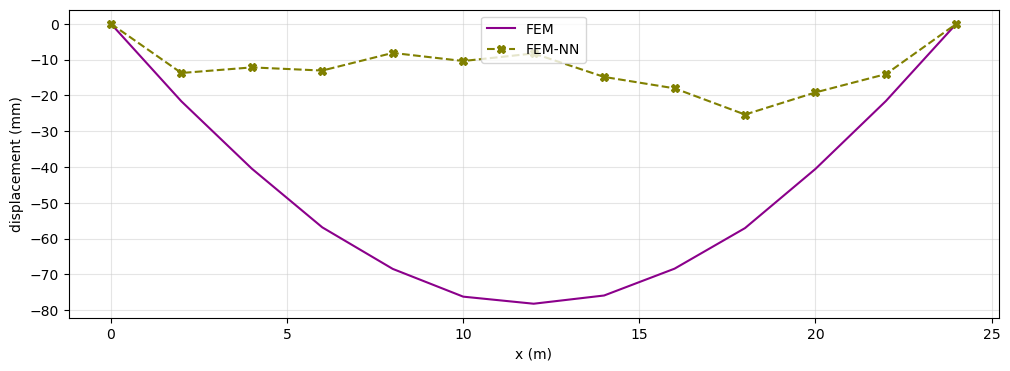

In [11]:
# Ploting both the solutions FEM and FEM_NN
x_axis = np.asarray([2*t for t in range(0, 13)])
plot_data_general(x_axis, np.asarray(y_act), pred_reshaped[:, 1], 'sudret',  ['FEM', 'FEM-NN'], ['x (m)', 'displacement (mm)'])